In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv('/content/global_cancer_patients_2015_2024 (1).csv')

In [ ]:
df.head(5)

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [ ]:
df.duplicated().sum()

np.int64(0)

Descriptive analysis

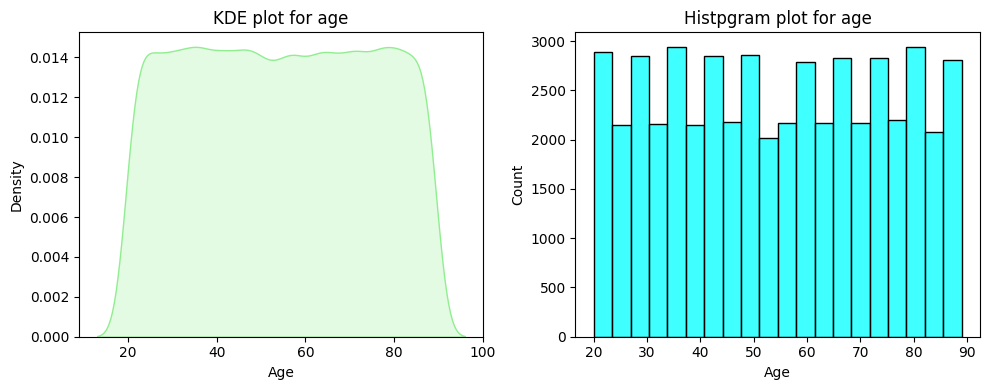

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.kdeplot(df['Age'],fill=True,color='lightgreen')
plt.title('KDE plot for age')

plt.subplot(1,2,2)
sns.histplot(df['Age'],bins=20,kde=False,color='cyan')
plt.title('Histpgram plot for age')

plt.tight_layout()
plt.show()

In [ ]:
df['Age'].describe()

,Age
count,50000.000000
mean,54.421540
std,20.224451
min,20.000000
25%,37.000000
50%,54.000000
75%,72.000000
max,89.000000


/tmp/ipython-input-1633424284.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Gender'].value_counts().index,


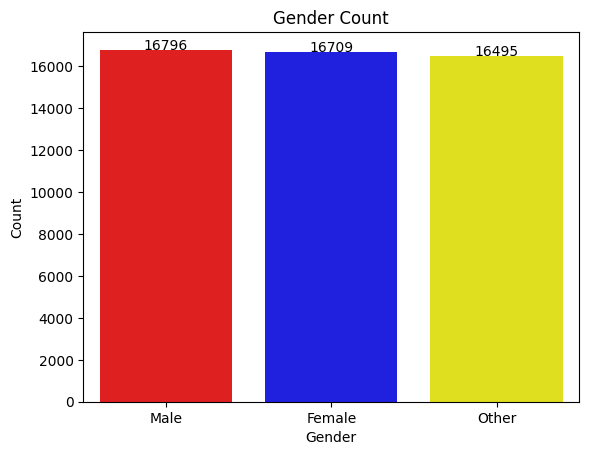

In [ ]:
sns.barplot(x=df['Gender'].value_counts().index,
            y=df['Gender'].value_counts().values,
            palette=['red','blue','yellow'])

for i,v in enumerate(df['Gender'].value_counts()):
  plt.text(i,v,str(v),ha='center')

plt.title('Gender Count')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [ ]:
df['Country_Region'].value_counts()

,count
Country_Region,
Australia,5092
UK,5060
USA,5060
India,5040
Germany,5024
Russia,5017
Brazil,5004
Pakistan,4926
China,4913


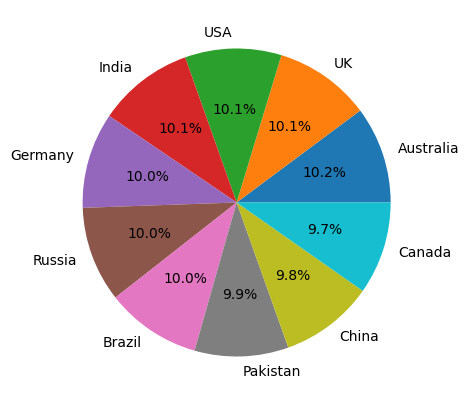

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(x=df['Country_Region'].value_counts().values,
        labels=df['Country_Region'].value_counts().index,
        autopct='%1.1f%%')
plt.show()


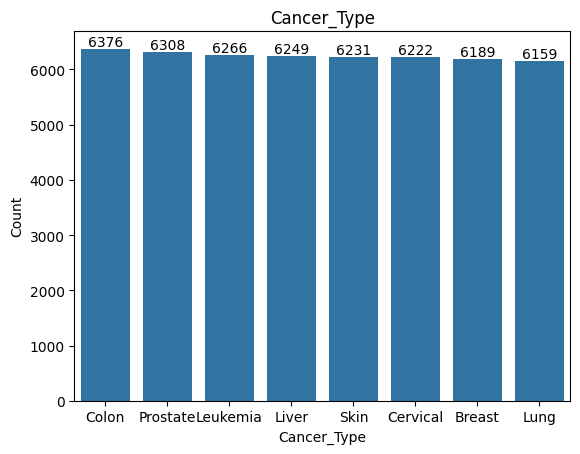

In [ ]:
sns.barplot(x=df['Cancer_Type'].value_counts().index,
            y=df['Cancer_Type'].value_counts().values)

for i,v in enumerate(df['Cancer_Type'].value_counts()):
  plt.text(i,v,str(v),ha='center',va='bottom')

plt.title('Cancer_Type')
plt.xlabel('Cancer_Type')
plt.ylabel('Count')
plt.show()

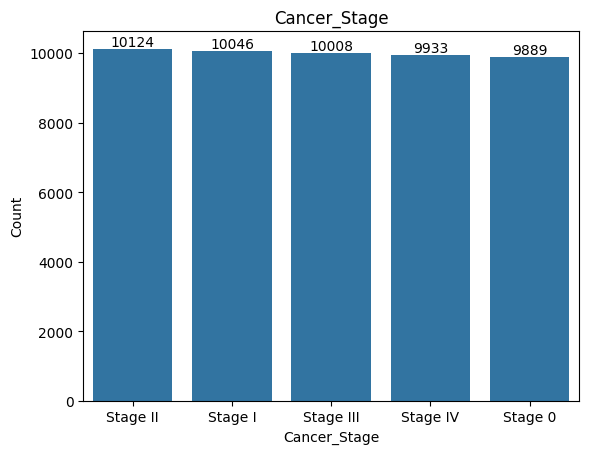

In [ ]:
sns.barplot(x=df['Cancer_Stage'].value_counts().index,
            y=df['Cancer_Stage'].value_counts().values)

for i,v in enumerate(df['Cancer_Stage'].value_counts()):
  plt.text(i,v,str(v),ha='center',va='bottom')

plt.title('Cancer_Stage')
plt.xlabel('Cancer_Stage')
plt.ylabel('Count')
plt.show()

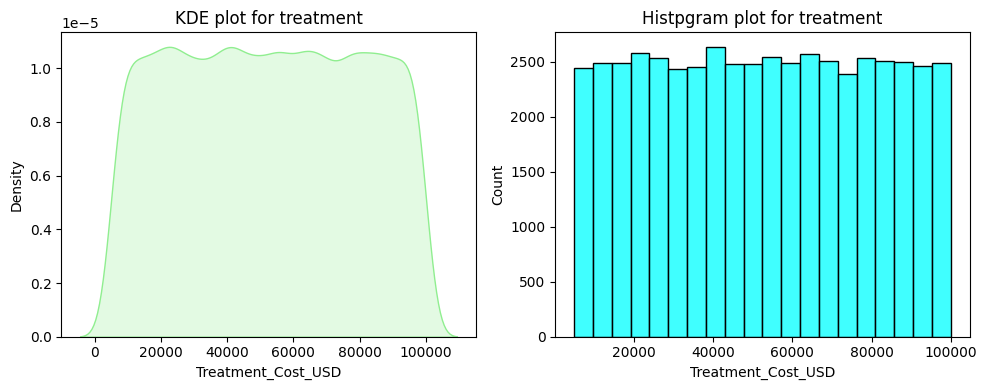

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.kdeplot(df['Treatment_Cost_USD'],fill=True,color='lightgreen')
plt.title('KDE plot for treatment')

plt.subplot(1,2,2)
sns.histplot(df['Treatment_Cost_USD'],bins=20,kde=False,color='cyan')
plt.title('Histpgram plot for treatment')

plt.tight_layout()
plt.show()

In [ ]:
df['Treatment_Cost_USD'].describe()

,Treatment_Cost_USD
count,50000.000000
mean,52467.298239
std,27363.229379
min,5000.050000
25%,28686.225000
50%,52474.310000
75%,76232.720000
max,99999.840000


In [ ]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

In [ ]:
risk_factors=['Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

summary=df[risk_factors].agg(['mean','std','min','max'])
summary

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


Determine the relationship between risk factors and cancer severity

In [ ]:
title=['Genetic Risk',
       'Air Pollution', 'Alcohol Use', 'Smoking', 'Obesity Level']
colors=['blue','green','cyan','yellow','red']

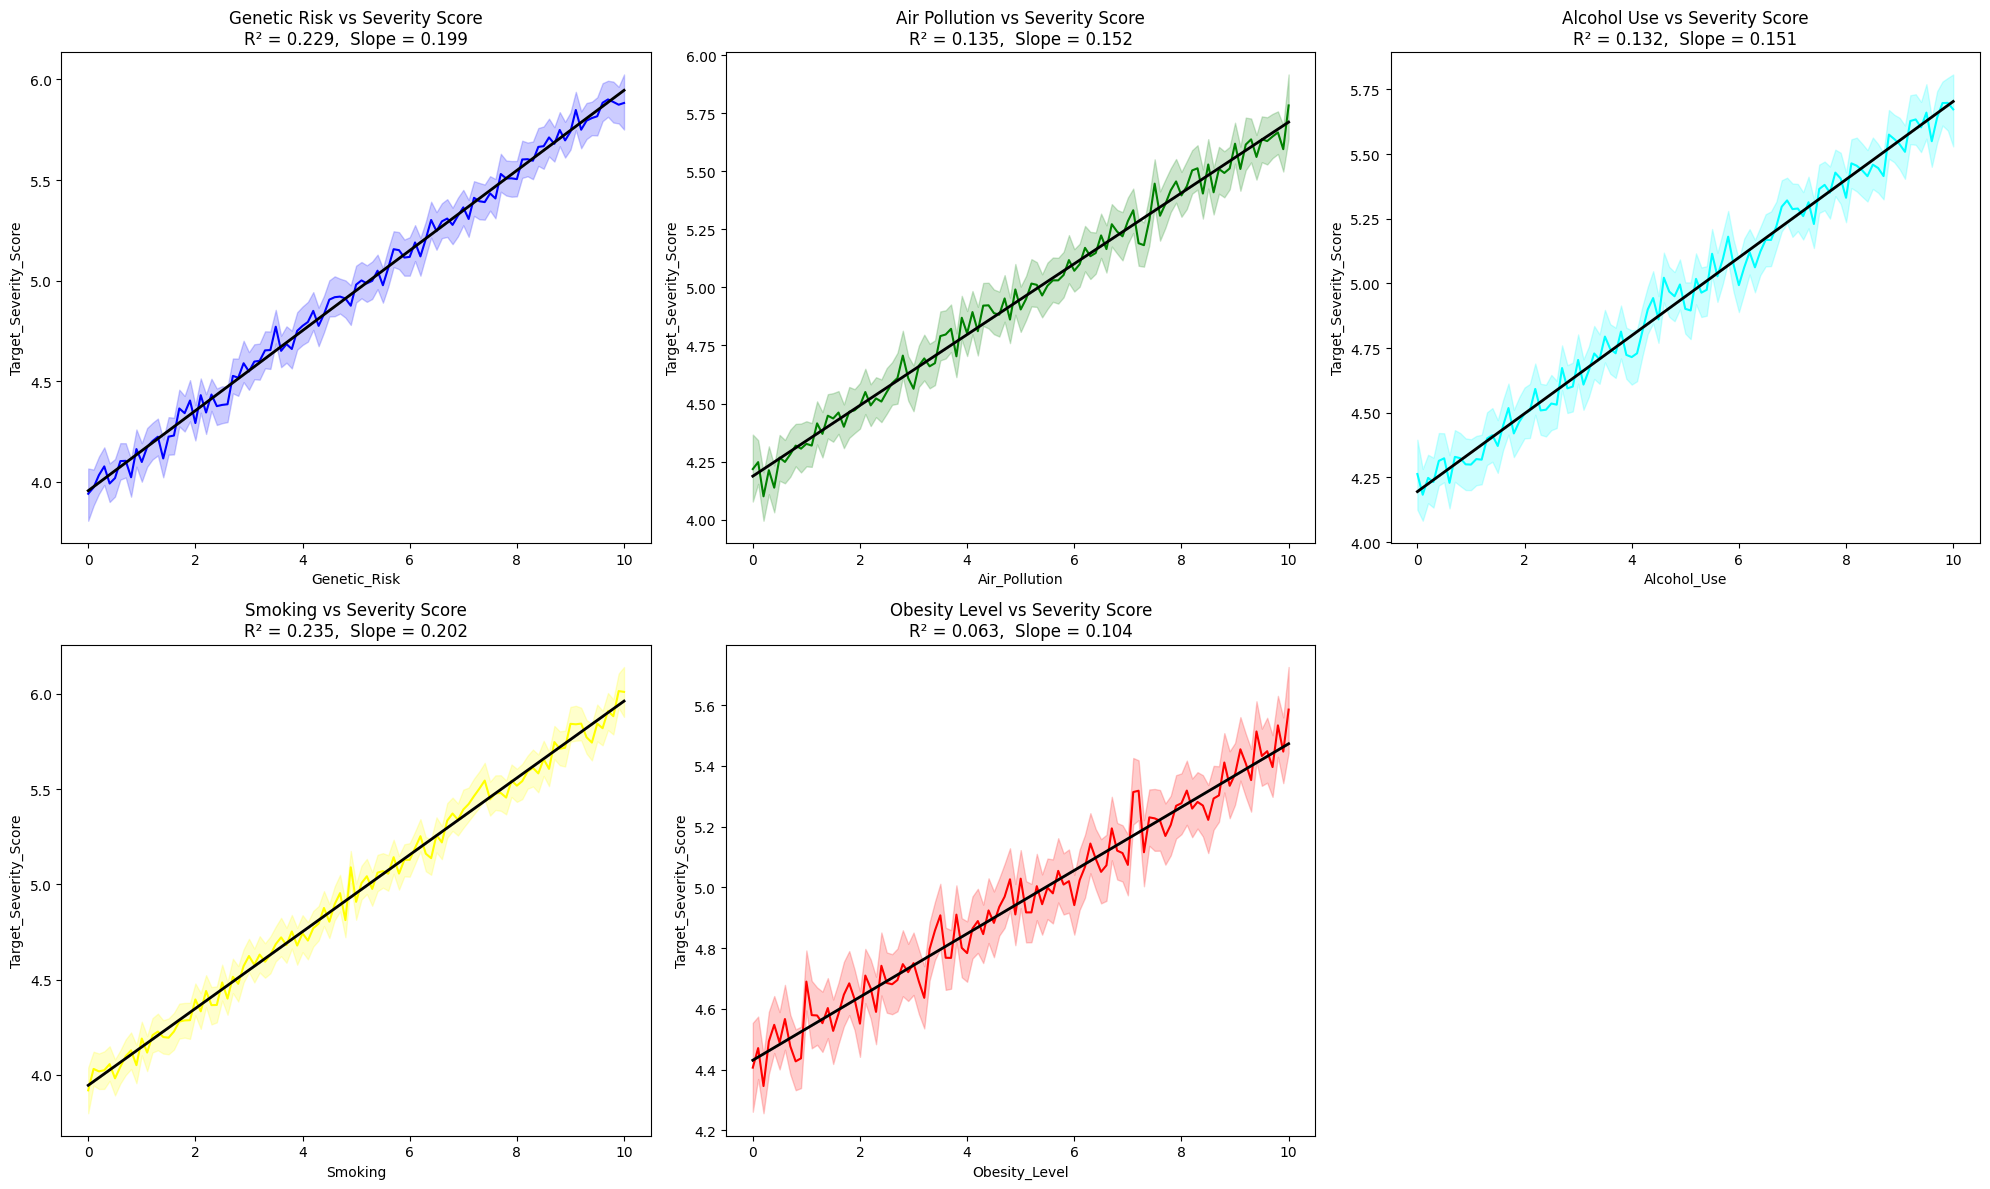

In [ ]:
from scipy.stats import linregress

plt.figure(figsize=(20,12))
for i,(factor,title,color) in enumerate(zip(risk_factors,title,colors),1):
  plt.subplot(2,3,i)
  x=df[factor]
  y=df['Target_Severity_Score']
  slope,intercept,r_value,p_value,std_err=linregress(x,y)
  r_squared=r_value**2
  sns.lineplot(x=factor,y='Target_Severity_Score',data=df
               ,color=color)
  sns.lineplot(x=x,y=x*slope+intercept,color='black',linewidth=2)
  plt.title(f"{title} vs Severity Score\n"
        f"R² = {r_squared:.3f},  Slope = {slope:.3f}")


plt.tight_layout()
plt.show()

Analyze the propotion of early-stage diagnoses by cancer type

In [ ]:
cancer_type=df['Cancer_Type'].unique()

In [ ]:
for cancer in cancer_type:
  stage_count=df[df['Cancer_Type']==cancer]['Cancer_Stage'].value_counts()
  stage_count_sum=stage_count.get('Stage 0',0)+stage_count.get('Stage I',1)
  stage_count_sum
  total=stage_count.sum()
  propotion=(stage_count_sum/total)*100
  print(f" propotion of {cancer} diagoned at early stage:{propotion}")

 propotion of Lung diagoned at early stage:38.43156356551388
 propotion of Leukemia diagoned at early stage:39.53080114905841
 propotion of Breast diagoned at early stage:39.47325900791727
 propotion of Colon diagoned at early stage:40.41718946047679
 propotion of Skin diagoned at early stage:40.41084898090194
 propotion of Cervical diagoned at early stage:39.85856637737062
 propotion of Prostate diagoned at early stage:40.187064045656314
 propotion of Liver diagoned at early stage:40.614498319731155


In [ ]:
df['Survival_Years'].describe()

,Survival_Years
count,50000.000000
mean,5.006462
std,2.883335
min,0.000000
25%,2.500000
50%,5.000000
75%,7.500000
max,10.000000


Key predictors of cancer severity and survival years

In [ ]:
features=['Age','Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

target=['Survival_Years','Target_Severity_Score']

In [ ]:
pearson_corr = df[features + target].corr(method='pearson')
pearson_corr=pearson_corr[target]
pearson_corr

,Survival_Years,Target_Severity_Score
Age,-0.000147,-0.001481
Genetic_Risk,0.001708,0.478700
Air_Pollution,0.000893,0.366963
Alcohol_Use,-0.000527,0.363250
Smoking,0.001371,0.484420
Obesity_Level,0.009771,0.251366
Survival_Years,1.000000,0.004161
Target_Severity_Score,0.004161,1.000000


In [ ]:
spearman_corr=df[features+target].corr(method='spearman')
spearman_corr=spearman_corr[target]

In [ ]:
correlation_df=pd.concat([pearson_corr,spearman_corr],axis=1,keys=['Pearson','Spearman'])

In [ ]:
correlation_df

Pearson                             Spearman  \
                      Survival_Years Target_Severity_Score Survival_Years   
Age                        -0.000147             -0.001481      -0.000149   
Genetic_Risk                0.001708              0.478700       0.001684   
Air_Pollution               0.000893              0.366963       0.000841   
Alcohol_Use                -0.000527              0.363250      -0.000543   
Smoking                     0.001371              0.484420       0.001372   
Obesity_Level               0.009771              0.251366       0.009780   
Survival_Years              1.000000              0.004161       1.000000   
Target_Severity_Score       0.004161              1.000000       0.003431   

                                             
                      Target_Severity_Score  
Age                               -0.002076  
Genetic_Risk                       0.472193  
Air_Pollution                      0.357528  
Alcohol_Use                        0.354694  
Smoking                            0.477881  
Obesity_Level                      0.243152  
Survival_Years                     0.003431  
Target_Severity_Score              1.000000

Survival years has no relation with any of the factors while Target_Severity Score has a moderate relation everyone except age.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

In [ ]:
df

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [ ]:
categorical_cals=['Gender','Country_Region','Cancer_Type','Cancer_Stage']

In [ ]:
for col in categorical_cals:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])

In [ ]:
x=df.drop(columns=['Patient_ID','Survival_Years','Target_Severity_Score','Treatment_Cost_USD'])

In [ ]:
y=df['Target_Severity_Score']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42)

In [ ]:
model=RandomForestRegressor(n_estimators=200,max_depth=None,min_samples_split=2,min_samples_leaf=1,random_state=42)

In [ ]:
model.fit(x_train,y_train)

KeyboardInterrupt: 

In [ ]:
y_pred_train=model.predict(x_train)
train_r2_score=r2_score(y_train,y_pred_train)
train_r2_score

In [ ]:
y_pred=model.predict(x_test)
test_r2_score=r2_score(y_test,y_pred)
test_r2_score

In [ ]:
feature_importance=pd.Series(model.feature_importances_,index=x.columns).sort_values(ascending=True)

In [ ]:
feature_importance

In [ ]:
plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar',color='blue')
plt.title('Feature extraction fot target score(Random Forest)')
plt.xlabel('Features')
plt.ylabel('score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
y=df['Survival_Years']
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# train the model
model = RandomForestRegressor(random_state=40)

GSC = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

GSC.fit(x_train, y_train)
best_estimators=GSC.best_estimators_
y_pred=best_estimators.predict(x_test)
test_r2_score=r2_score(y_test,y_pred)
test_r2_score
feature_importance=pd.Series(best_estimators.feature_importances_,index=x.columns).sort_values(ascending=True)

Explore the economic burden of cancer treatment across different demographics

In [ ]:
data=pd.read_csv('/content/global_cancer_patients_2015_2024 (1).csv')

In [ ]:
country_gender_wise_cost=data.groupby(['Country_Region','Gender'])['Treatment_Cost_USD'].mean().reset_index()
country_gender_wise_cost

,Country_Region,Gender,Treatment_Cost_USD
0,Australia,Female,52301.781302
1,Australia,Male,52928.509540
2,Australia,Other,52629.969316
3,Brazil,Female,52484.894936
4,Brazil,Male,52937.613970
5,Brazil,Other,52186.267723
6,Canada,Female,52358.507421
7,Canada,Male,52846.880795
8,Canada,Other,52559.389020
9,China,Female,52438.973622


In [ ]:
data['Age_Group'] = pd.cut(
    data['Age'],
    bins=[0, 30, 45, 60, 75, 100],
    labels=['0-30', '31-45', '46-60', '61-75', '76+']
)
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Age_Group
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92,61-75
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65,31-45
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84,76+
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12,31-45
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63,76+
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03,31-45
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02,61-75
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54,0-30


In [ ]:
country_age_gender_wise_cost=data.groupby(['Country_Region','Age_Group','Gender'])['Treatment_Cost_USD'].mean().reset_index()
country_age_gender_wise_cost

/tmp/ipython-input-381930134.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_age_gender_wise_cost=data.groupby(['Country_Region','Age_Group','Gender'])['Treatment_Cost_USD'].mean().reset_index()


,Country_Region,Age_Group,Gender,Treatment_Cost_USD
0,Australia,0-30,Female,53287.701319
1,Australia,0-30,Male,52939.875035
2,Australia,0-30,Other,53776.208452
3,Australia,31-45,Female,51647.694000
4,Australia,31-45,Male,54212.453438
...,...,...,...,...
145,USA,61-75,Male,55381.892304
146,USA,61-75,Other,52070.474766
147,USA,76+,Female,51877.032768
148,USA,76+,Male,52445.346342


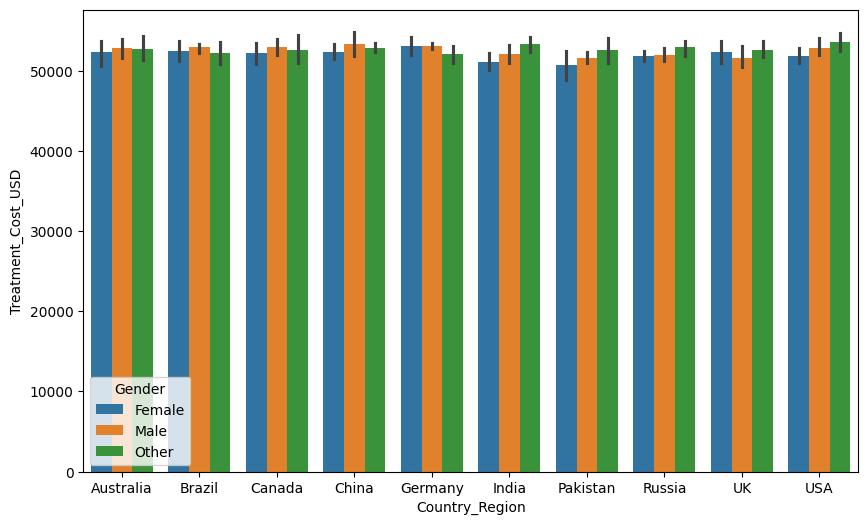

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Country_Region',y='Treatment_Cost_USD',data=country_age_gender_wise_cost,hue='Gender')
plt.show()

In [ ]:
country_age_wise_cost=data.groupby(['Country_Region','Age_Group'])['Treatment_Cost_USD'].mean().reset_index()
heat_map=country_age_wise_cost.pivot(index='Age_Group',columns='Country_Region',values='Treatment_Cost_USD')

/tmp/ipython-input-2769404379.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_age_wise_cost=data.groupby(['Country_Region','Age_Group'])['Treatment_Cost_USD'].mean().reset_index()


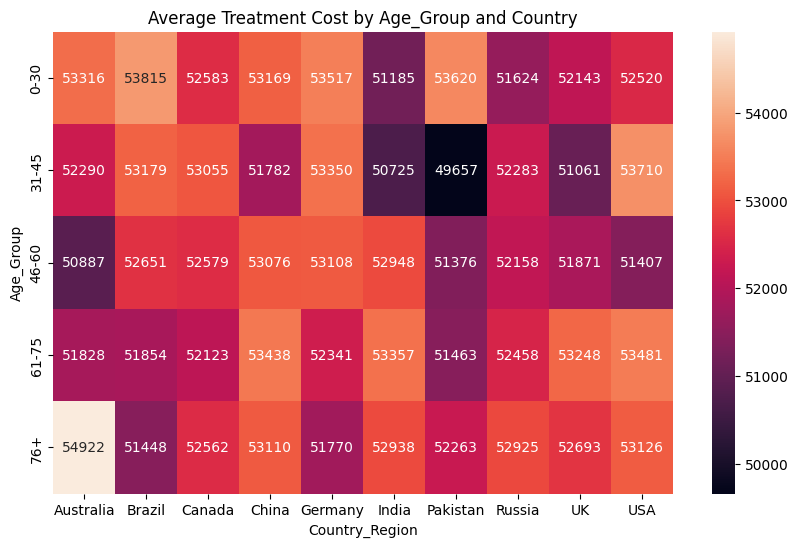

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(heat_map,annot=True,fmt='.0f')
plt.title('Average Treatment Cost by Age_Group and Country')
plt.show()

Assess whether higher treatment cost is associated with longer survival

In [ ]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Age_Group
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92,61-75
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65,31-45
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84,76+
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12,31-45
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63,76+
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03,31-45
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02,61-75
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54,0-30


In [ ]:
from scipy.stats import pearsonr,spearmanr

x=data['Survival_Years']
y=data['Treatment_Cost_USD']
pearson_corr,pearson_p=pearsonr(x,y)
print(pearson_corr)
print(pearson_p)

-0.00042940542830214993
0.9235082012963275


In [ ]:
x=data['Survival_Years']
y=data['Treatment_Cost_USD']
spearman_corr,spearman_p=spearmanr(x,y)
print(spearman_corr)
print(spearman_p)

-0.0004454737292549569
0.9206551702014918


In [ ]:
alpha=0.05

def interpret_corr(corr,p,method):
  if p<alpha:
    print(f'{method} we reject the null hypo')
  else:
    print(f'{method} we fail to reject the null hypo')

interpret_corr(pearson_corr,pearson_p,'pearson')
interpret_corr(spearman_corr,spearman_p,'spearman')

pearson we fail to reject the null hypo
spearman we fail to reject the null hypo


<Axes: xlabel='Survival_Years', ylabel='Treatment_Cost_USD'>

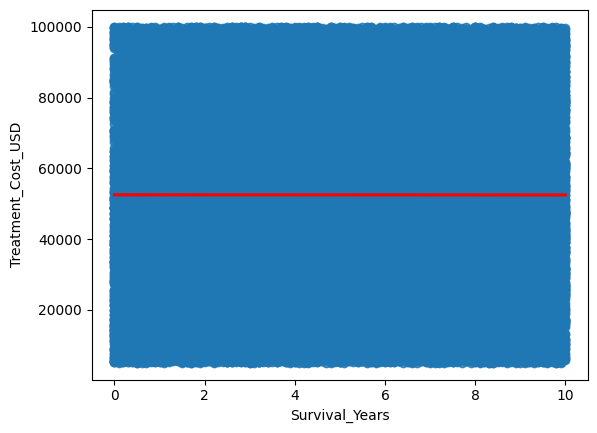

In [ ]:
sns.regplot(x=x,y=y,line_kws={'color':'red'})

Evaluate if higher cancer stages lead to greater treatment costs and reduced survival years


In [ ]:
data_new=data.copy()
data_new

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Age_Group
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92,61-75
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65,31-45
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84,76+
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12,31-45
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63,76+
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03,31-45
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02,61-75
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54,0-30


In [ ]:
stage_cancer=['Stage 0','Stage I','Stage II','Stage III','Stage IV']

In [ ]:
group_stats=data_new.groupby('Cancer_Stage')[['Treatment_Cost_USD','Survival_Years']].mean().reset_index()
group_stats

,Cancer_Stage,Treatment_Cost_USD,Survival_Years
0,Stage 0,52572.589493,5.015199
1,Stage I,52674.079638,5.012990
2,Stage II,52082.841258,4.995170
3,Stage III,52708.197506,5.036311
4,Stage IV,52302.471041,4.972596


In [ ]:
 group_costs=[]
 group_survival=[]

 for stage in stage_cancer:
  stage_data=data_new[data_new['Cancer_Stage']==stage]
  cost=stage_data['Treatment_Cost_USD']
  survival=stage_data['Survival_Years']
  group_costs.append(cost)
  group_survival.append(survival)

In [ ]:
from scipy.stats import shapiro

cost_normal=0
survival_normal=0

for i in  range (len(group_costs)):
  cost_p=shapiro(group_costs[i]).pvalue
  survival_p=shapiro(group_survival[i]).pvalue
  if cost_p<0.05:
    cost_normal=cost_normal+1
  if survival_p<0.05:
    survival_normal=survival_normal+1

print(cost_normal)
print(survival_normal)


5
5


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9889.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10046.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10124.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10008.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.s

In [ ]:
from scipy.stats import kruskal
kruskal_p_cost=kruskal(*group_costs).pvalue
kruskal_p_survival=kruskal(*group_survival).pvalue

Examine whether higher genetic risk amplifies the negative effects of smoking on cancer severity

In [ ]:
pip install statsmodels

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
model=smf.ols('Target_Severity_Score~Genetic_Risk*Smoking',data=data).fit()
model.summary2().tables[1].loc['Genetic_Risk:Smoking']

,Genetic_Risk:Smoking
Coef.,-0.000228
Std.Err.,0.000471
t,-0.484187
P>|t|,0.628255
[0.025,-0.001150
0.975],0.000694


In [ ]:
p_value=0.628255